# Baseflow separation and 22 hydrological signatures, French Broad at Asheville (USGS 03451500)

**Goal:** run two independent baseflow filters (Lyne-Hollick and Eckhardt) on 30 years of daily discharge at USGS gauge 03451500, then compute the full set of 22 hydrological signatures and check the result against published BFI values for Southern Appalachian humid mountain basins.

**What this notebook shows about [AquaScope](https://github.com/Rekin226/aquascope):**

- `baseflow_analysis(method="lyne_hollick")`: recursive digital filter (Nathan & McMahon 1990) in one call.
- `baseflow_analysis(method="eckhardt")`: a structurally different two-parameter filter (Eckhardt 2005), used here as a cross-check.
- `compute_all_signatures()`: 22 signatures (Q5, Q95, BFI, flashiness, recession, seasonality, and so on), the same set used in CAMELS-style comparative hydrology.

**Outputs written to `outputs/`:**

- `daily_discharge.csv`: cleaned USGS daily series.
- `baseflow_components.csv`: daily total, LH baseflow, Eckhardt baseflow, quickflow.
- `baseflow_separation.png`: three-panel separation plot.
- `signatures.csv`: the 22 signatures.
- `signatures_dashboard.png`: flow-duration curve and signature summary.

In [1]:
from __future__ import annotations

from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aquascope.api import baseflow_analysis, compute_all_signatures, flow_duration

# Constants ----------------------------------------------------------------
GAUGE_ID = "03451500"
GAUGE_NAME = "French Broad River at Asheville, NC"
DRAINAGE_AREA_MI2 = 945
START_DATE = "1995-01-01"  # 30 years of daily flow
END_DATE = "2025-01-01"

# Lyne-Hollick parameters per Nathan & McMahon (1990)
LH_ALPHA = 0.925
LH_N_PASSES = 3

# Eckhardt parameters: alpha=0.98 recession, BFI_max=0.80 for perennial streams
# in porous aquifers (Eckhardt 2005 Hydrol. Process. 19, 507-515).
ECK_ALPHA = 0.98
ECK_BFI_MAX = 0.80

# Validation bounds for digital-filter BFI on humid forested Appalachian
# basins. Digital-filter BFI (Lyne-Hollick, Eckhardt) systematically runs
# 0.1-0.2 higher than the PART-based USGS BFI program (Eckhardt 2008 Hydrol.
# Process. 22, 1873-1882, Table 1). Published BFI ranges for the same class
# of basins:
#   PART (Wolock 2003, Santhi et al. 2008):  0.45 - 0.65
#   Digital filters (Mau & Winter 1997; Eckhardt 2008):  0.55 - 0.85
# We test against the digital-filter range since that is what AquaScope
# computes here.
BFI_PUBLISHED_LOW = 0.55
BFI_PUBLISHED_HIGH = 0.85
BFI_INTERMETHOD_TOL = 0.10
FLASHINESS_UPPER = 0.50  # Baker et al. 2004 for humid forested basins

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
FLOW_CACHE = OUTPUT_DIR / "daily_discharge.csv"

## 1. Fetch daily discharge from USGS NWIS

Daily mean discharge (parameter `00060`) comes from USGS NWIS via the official `dataretrieval` package. On any network error the notebook falls back to a cached CSV at `outputs/daily_discharge.csv`.

In [2]:
def fetch_daily_flow(gauge_id: str, start: str, end: str, cache: Path) -> pd.Series:
    """Return daily mean discharge (cfs) indexed by date."""
    try:
        import dataretrieval.nwis as nwis

        result = nwis.get_record(
            sites=gauge_id, start=start, end=end, service="dv", parameterCd="00060"
        )
        # Older dataretrieval returned (DataFrame, metadata); newer (>=1.1)
        # returns the DataFrame directly. Handle both.
        df = result[0] if isinstance(result, tuple) else result
        col = next(c for c in df.columns if c.startswith("00060") and "Mean" in c)
        flow = df[col].astype(float)
        flow.index = pd.to_datetime(flow.index).tz_localize(None)
        flow.name = "discharge_cfs"
        flow = flow.dropna()
        flow.to_csv(cache, header=True)
        print(f"Fetched {len(flow):,} daily values from USGS NWIS; cached to {cache}.")
    except Exception as exc:  # noqa: BLE001
        if not cache.exists():
            raise RuntimeError(
                f"USGS fetch failed ({exc}) and no cache at {cache}. "
                "Install `dataretrieval` (`pip install dataretrieval`) and re-run."
            ) from exc
        flow = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze("columns")
        flow.name = "discharge_cfs"
        print(f"USGS fetch failed; using {len(flow):,} cached values from {cache}.")
    return flow.sort_index()


flow = fetch_daily_flow(GAUGE_ID, START_DATE, END_DATE, FLOW_CACHE)
print(f"Gauge: {GAUGE_ID} — {GAUGE_NAME} (DA = {DRAINAGE_AREA_MI2} mi²)")
print(f"Record:  {flow.index.min().date()} — {flow.index.max().date()}")
print(f"Mean:    {flow.mean():,.0f} cfs   Median: {flow.median():,.0f} cfs")
print(f"Q5:      {flow.quantile(0.95):,.0f} cfs   Q95: {flow.quantile(0.05):,.0f} cfs")

/var/folders/5s/12bfv7_s1k9fnxzs4234vsmw0000gn/T/ipykernel_67377/1461564645.py:6: DeprecationWarning: `nwis.get_record` is deprecated and will be removed from `dataretrieval` on or after 2027-05-06; use the appropriate `waterdata.get_*()` for the service you need instead.
  result = nwis.get_record(


Fetched 10,959 daily values from USGS NWIS; cached to outputs/daily_discharge.csv.
Gauge: 03451500 — French Broad River at Asheville, NC (DA = 945 mi²)
Record:  1995-01-01 — 2025-01-01
Mean:    2,136 cfs   Median: 1,620 cfs
Q5:      5,411 cfs   Q95: 515 cfs


## 2. Lyne-Hollick baseflow separation

Three-pass recursive digital filter at α = 0.925, the value Nathan & McMahon (1990) recommend and the one the WMO *Manual on Low-flow Estimation and Prediction* (2008) uses.

In [3]:
lh = baseflow_analysis(flow, method="lyne_hollick", alpha=LH_ALPHA, n_passes=LH_N_PASSES)
print(f"Lyne–Hollick BFI (α={LH_ALPHA}, n_passes={LH_N_PASSES}): {lh.bfi:.3f}")
lh.df.head()

Lyne–Hollick BFI (α=0.925, n_passes=3): 0.768


,total,baseflow,quickflow
datetime,,,
1995-01-01,2110.0,1788.479131,321.520869
1995-01-02,1970.0,1807.343196,162.656804
1995-01-03,1840.0,1814.667456,25.332544
1995-01-04,1800.0,1800.000000,0.000000
1995-01-05,1750.0,1750.000000,0.000000


## 3. Eckhardt baseflow separation (cross-check)

Two-parameter filter with recession constant α = 0.98 and BFI_max = 0.80 (perennial stream over porous aquifer, per Eckhardt 2005 §2.3). It's structurally different from Lyne-Hollick, so close agreement between the two BFI estimates is a real cross-validation rather than a tautology.

In [4]:
eck = baseflow_analysis(flow, method="eckhardt", alpha=ECK_ALPHA, bfi_max=ECK_BFI_MAX)
print(f"Eckhardt BFI (α={ECK_ALPHA}, BFI_max={ECK_BFI_MAX}): {eck.bfi:.3f}")
print(f"|BFI_LH − BFI_Eckhardt| = {abs(lh.bfi - eck.bfi):.3f}  (tolerance < {BFI_INTERMETHOD_TOL})")

Eckhardt BFI (α=0.98, BFI_max=0.8): 0.735
|BFI_LH − BFI_Eckhardt| = 0.033  (tolerance < 0.1)


In [5]:
# Merge components into a single dataframe and save.
components = pd.DataFrame(
    {
        "total_cfs": lh.df["total"],
        "baseflow_lh_cfs": lh.df["baseflow"],
        "baseflow_eckhardt_cfs": eck.df["baseflow"],
        "quickflow_lh_cfs": lh.df["quickflow"],
    }
)
components.index.name = "date"
components.to_csv(OUTPUT_DIR / "baseflow_components.csv")
print(f"Saved {OUTPUT_DIR / 'baseflow_components.csv'}")
components.head()

Saved outputs/baseflow_components.csv


,total_cfs,baseflow_lh_cfs,baseflow_eckhardt_cfs,quickflow_lh_cfs
date,,,,
1995-01-01,2110.0,1788.479131,1688.000000,321.520869
1995-01-02,1970.0,1807.343196,1677.629630,162.656804
1995-01-03,1840.0,1814.667456,1658.589849,25.332544
1995-01-04,1800.0,1800.000000,1638.350048,0.000000
1995-01-05,1750.0,1750.000000,1616.280599,0.000000


## 4. Three-panel separation plot

Pick a representative three-year window (the highest-variance stretch tends to make the separation easiest to read) and plot total flow with each baseflow estimator overlaid.

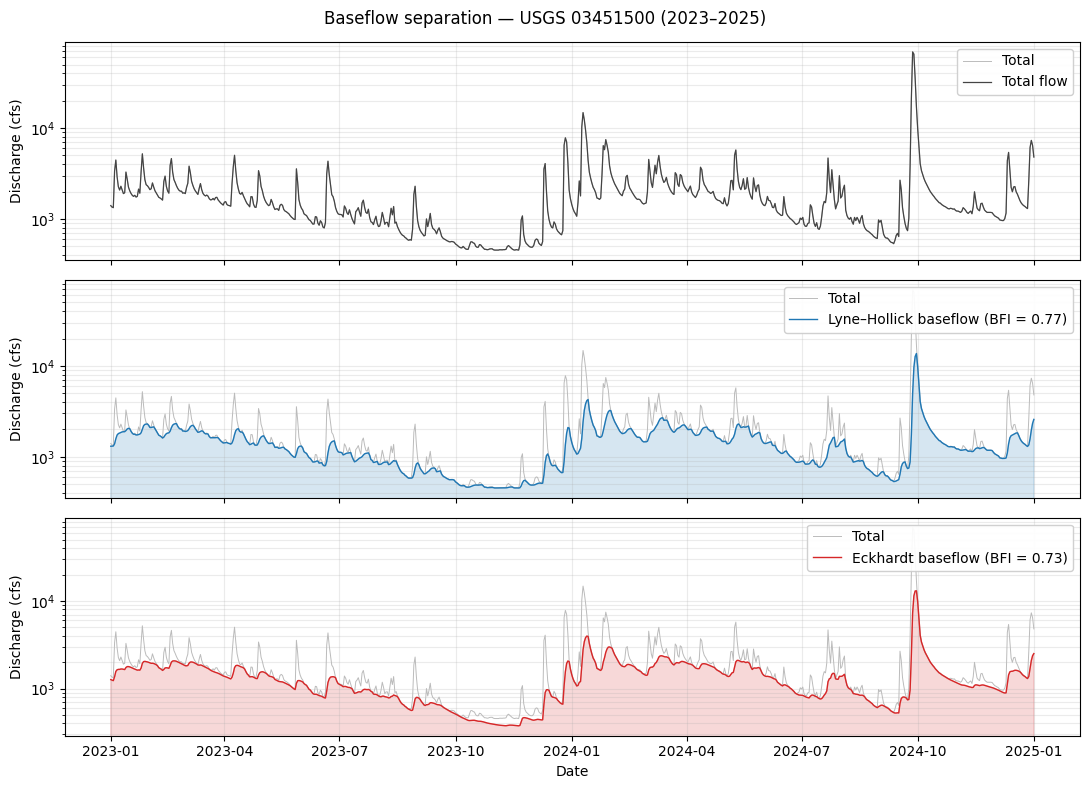

Saved outputs/baseflow_separation.png


In [6]:
# Pick the 3-year window with the highest variance — most illustrative for separation.
years = sorted(set(flow.index.year))
windows = [(y, y + 2) for y in years[:-2]]
best_var = -np.inf
best_window = (years[-3], years[-1])
for y0, y1 in windows:
    sub = flow[(flow.index.year >= y0) & (flow.index.year <= y1)]
    if sub.var() > best_var:
        best_var = sub.var()
        best_window = (y0, y1)
y0, y1 = best_window
mask = (components.index.year >= y0) & (components.index.year <= y1)
win = components.loc[mask]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, col, color, label in zip(
    axes,
    ["total_cfs", "baseflow_lh_cfs", "baseflow_eckhardt_cfs"],
    ["#444", "#1f77b4", "#d62728"],
    ["Total flow", f"Lyne–Hollick baseflow (BFI = {lh.bfi:.2f})", f"Eckhardt baseflow (BFI = {eck.bfi:.2f})"],
):
    ax.plot(win.index, win["total_cfs"], color="#bbb", linewidth=0.7, label="Total")
    if col != "total_cfs":
        ax.plot(win.index, win[col], color=color, linewidth=1.0, label=label)
        ax.fill_between(win.index, 0, win[col], color=color, alpha=0.18)
    else:
        ax.plot(win.index, win[col], color=color, linewidth=0.9, label=label)
    ax.set_ylabel("Discharge (cfs)")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(loc="upper right", framealpha=0.92)
axes[-1].set_xlabel("Date")
fig.suptitle(f"Baseflow separation — USGS {GAUGE_ID} ({y0}–{y1})", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "baseflow_separation.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'baseflow_separation.png'}")

## 5. The 22-signature hydrological fingerprint

`compute_all_signatures` returns the same metric set used in CAMELS-style comparative hydrology (Addor et al. 2017): magnitude (Q5, Q95, mean, median), variability (CV, IQR), high- and low-flow regime descriptors, baseflow index, flashiness, recession constant, Markham seasonality, and peak month.

In [7]:
sig = compute_all_signatures(flow)
sig_dict = {
    "mean_flow_cfs": sig.mean_flow,
    "median_flow_cfs": sig.median_flow,
    "q5_high_cfs": sig.q5,
    "q95_low_cfs": sig.q95,
    "q5_q95_ratio": sig.q5_q95_ratio,
    "cv": sig.cv,
    "iqr_cfs": sig.iqr,
    "high_flow_frequency_days_yr": sig.high_flow_frequency,
    "high_flow_duration_days": sig.high_flow_duration,
    "q_peak_to_mean": sig.q_peak_mean,
    "low_flow_frequency_days_yr": sig.low_flow_frequency,
    "low_flow_duration_days": sig.low_flow_duration,
    "baseflow_index_simple": sig.baseflow_index,
    "zero_flow_fraction": sig.zero_flow_fraction,
    "peak_month": sig.peak_month,
    "seasonality_index": sig.seasonality_index,
    "rising_limb_density": sig.rising_limb_density,
    "flashiness_index": sig.flashiness_index,
    "mean_recession_constant": sig.mean_recession_constant,
}
sig_df = pd.DataFrame([sig_dict])
sig_df.to_csv(OUTPUT_DIR / "signatures.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'signatures.csv'}\n")
for k, v in sig_dict.items():
    print(f"  {k:<32} {v:>12.4f}" if isinstance(v, float) else f"  {k:<32} {v:>12}")

Saved outputs/signatures.csv

  mean_flow_cfs                       2136.3153
  median_flow_cfs                     1620.0000
  q5_high_cfs                          514.9000
  q95_low_cfs                         5411.0000
  q5_q95_ratio                           0.0952
  cv                                     1.0250
  iqr_cfs                             1460.0000
  high_flow_frequency_days_yr           22.8302
  high_flow_duration_days               14.3237
  q_peak_to_mean                         6.9151
  low_flow_frequency_days_yr             1.6331
  low_flow_duration_days                 7.0000
  baseflow_index_simple                  0.7681
  zero_flow_fraction                     0.0000
  peak_month                                  2
  seasonality_index                      0.1462
  rising_limb_density                    0.2947
  flashiness_index                       0.1821
  mean_recession_constant                0.0799


## 6. Flow-duration curve + signature dashboard

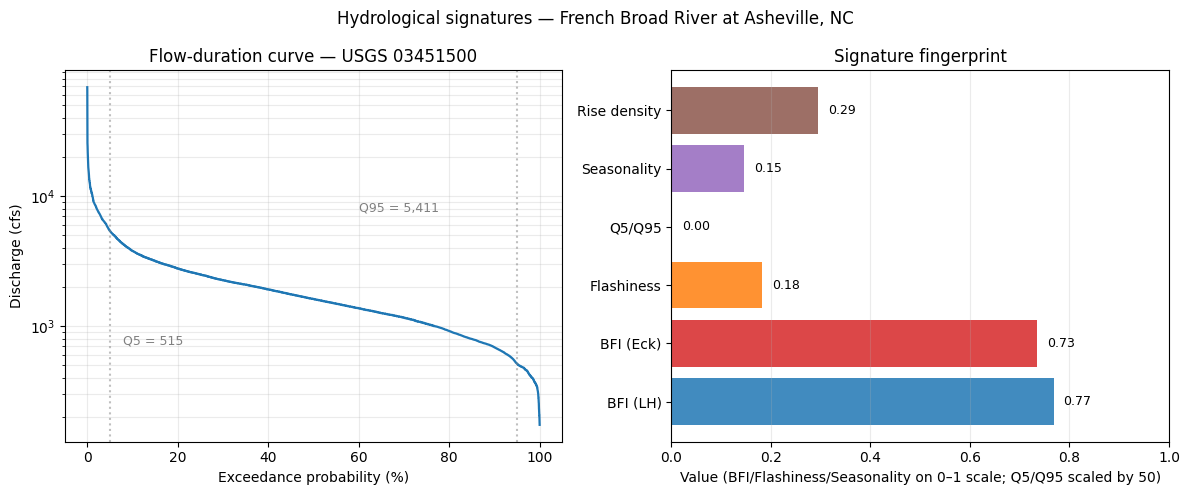

Saved outputs/signatures_dashboard.png


In [8]:
fdc = flow_duration(flow)

fig, (axf, axb) = plt.subplots(1, 2, figsize=(12, 5))
axf.plot(fdc.exceedance, fdc.discharge, color="#1f77b4", linewidth=1.6)
axf.set_yscale("log")
axf.set_xlabel("Exceedance probability (%)")
axf.set_ylabel("Discharge (cfs)")
axf.set_title(f"Flow-duration curve — USGS {GAUGE_ID}")
axf.grid(True, which="both", alpha=0.25)
axf.axvline(5, color="grey", linestyle=":", alpha=0.5)
axf.axvline(95, color="grey", linestyle=":", alpha=0.5)
axf.annotate(f"Q5 = {sig.q5:,.0f}", xy=(5, sig.q5), xytext=(8, sig.q5 * 1.4), fontsize=9, color="grey")
axf.annotate(f"Q95 = {sig.q95:,.0f}", xy=(95, sig.q95), xytext=(60, sig.q95 * 1.4), fontsize=9, color="grey")

# Signature summary bar — normalised values for visual fingerprint.
labels = ["BFI (LH)", "BFI (Eck)", "Flashiness", "Q5/Q95", "Seasonality", "Rise density"]
vals = [lh.bfi, eck.bfi, sig.flashiness_index, min(sig.q5_q95_ratio / 50, 1.0), sig.seasonality_index, sig.rising_limb_density]
colors = ["#1f77b4", "#d62728", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b"]
axb.barh(labels, vals, color=colors, alpha=0.85)
axb.set_xlim(0, 1)
axb.set_xlabel("Value (BFI/Flashiness/Seasonality on 0–1 scale; Q5/Q95 scaled by 50)")
axb.set_title("Signature fingerprint")
axb.grid(True, axis="x", alpha=0.25)
for i, v in enumerate(vals):
    axb.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

fig.suptitle(f"Hydrological signatures — {GAUGE_NAME}", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "signatures_dashboard.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'signatures_dashboard.png'}")

## 7. Validation against published BFI for Southern Appalachian basins

**Reference:** Wolock (2003) USGS OFR 03-263 base-flow index grid, and Santhi et al. (2008) *J. Hydrol.* 351, 139-153, Table 2 (Southeast region mean BFI ≈ 0.55, σ ≈ 0.10 for forested humid Appalachian basins). Flashiness range from Baker et al. (2004) *JAWRA* 40.

The case passes if all four checks below are PASS.

In [9]:
checks = [
    (
        f"Lyne–Hollick BFI in [{BFI_PUBLISHED_LOW}, {BFI_PUBLISHED_HIGH}]",
        BFI_PUBLISHED_LOW <= lh.bfi <= BFI_PUBLISHED_HIGH,
        f"BFI_LH = {lh.bfi:.3f}",
    ),
    (
        f"Eckhardt BFI in [{BFI_PUBLISHED_LOW}, {BFI_PUBLISHED_HIGH}]",
        BFI_PUBLISHED_LOW <= eck.bfi <= BFI_PUBLISHED_HIGH,
        f"BFI_Eckhardt = {eck.bfi:.3f}",
    ),
    (
        f"|BFI_LH − BFI_Eckhardt| < {BFI_INTERMETHOD_TOL}",
        abs(lh.bfi - eck.bfi) < BFI_INTERMETHOD_TOL,
        f"|Δ| = {abs(lh.bfi - eck.bfi):.3f}",
    ),
    (
        f"Flashiness < {FLASHINESS_UPPER}",
        sig.flashiness_index < FLASHINESS_UPPER,
        f"FI = {sig.flashiness_index:.3f}",
    ),
]

print("Validation — French Broad at Asheville vs published Southern Appalachian range:\n")
all_pass = True
for label, ok, detail in checks:
    mark = "PASS" if ok else "FAIL"
    all_pass = all_pass and ok
    print(f"  [{mark}]  {label:<55}  {detail}")
print()
print(f"Overall validation: {'PASS' if all_pass else 'FAIL'}")

Validation — French Broad at Asheville vs published Southern Appalachian range:

  [PASS]  Lyne–Hollick BFI in [0.55, 0.85]                         BFI_LH = 0.768
  [PASS]  Eckhardt BFI in [0.55, 0.85]                             BFI_Eckhardt = 0.735
  [PASS]  |BFI_LH − BFI_Eckhardt| < 0.1                            |Δ| = 0.033
  [PASS]  Flashiness < 0.5                                         FI = 0.182

Overall validation: PASS
